In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from config import rng, N_NEURONS, NOISE_STD_POP, TRUE_ANGLES_DEG
from utils import wrap_angle_deg, angular_error_deg

In [2]:
pref_dirs_deg = np.linspace(0, 360, N_NEURONS, endpoint=False)
pref_dirs_rad = np.deg2rad(pref_dirs_deg)
pref_vecs = np.column_stack([np.cos(pref_dirs_rad), np.sin(pref_dirs_rad)])

true_angles_rad = np.deg2rad(TRUE_ANGLES_DEG)

In [3]:
# --- TODO 1: Define cosine tuning function ---
def cosine_tuning(theta, phi):
    # Standard cosine tuning: max(0, cos(difference))
    return np.maximum(0, np.cos(theta - phi))

In [4]:
# --- TODO 2: Decode each movement direction ---
decoded_angles_deg = []
all_rates_matrix = []

for theta in true_angles_rad:
    # 1. Compute noiseless rates for all neurons at once
    rates = cosine_tuning(theta, pref_dirs_rad)
    
    # 2. Add noise and clip
    rates += rng.normal(0, NOISE_STD_POP, size=N_NEURONS)
    rates = np.maximum(0, rates)
    
    # 3. Population Vector: Sum of (rate * preferred_unit_vector)
    # pref_vecs is (N_NEURONS, 2)
    pv = np.sum(rates[:, np.newaxis] * pref_vecs, axis=0)
    
    # 4. Decode angle using arctan2(y, x)
    decoded_rad = np.arctan2(pv[1], pv[0])
    decoded_deg = np.rad2deg(decoded_rad)
    
    # 5. Wrap to [0, 360)
    decoded_deg = wrap_angle_deg(decoded_deg)
    
    decoded_angles_deg.append(decoded_deg)
    all_rates_matrix.append(rates)

decoded_angles_deg = np.array(decoded_angles_deg)
all_rates_matrix = np.array(all_rates_matrix)

In [5]:
# --- TODO 3: Compute angular decoding error ---
angular_errors = angular_error_deg(decoded_angles_deg, TRUE_ANGLES_DEG)
mae = np.mean(np.abs(angular_errors))
max_err = np.max(np.abs(angular_errors))

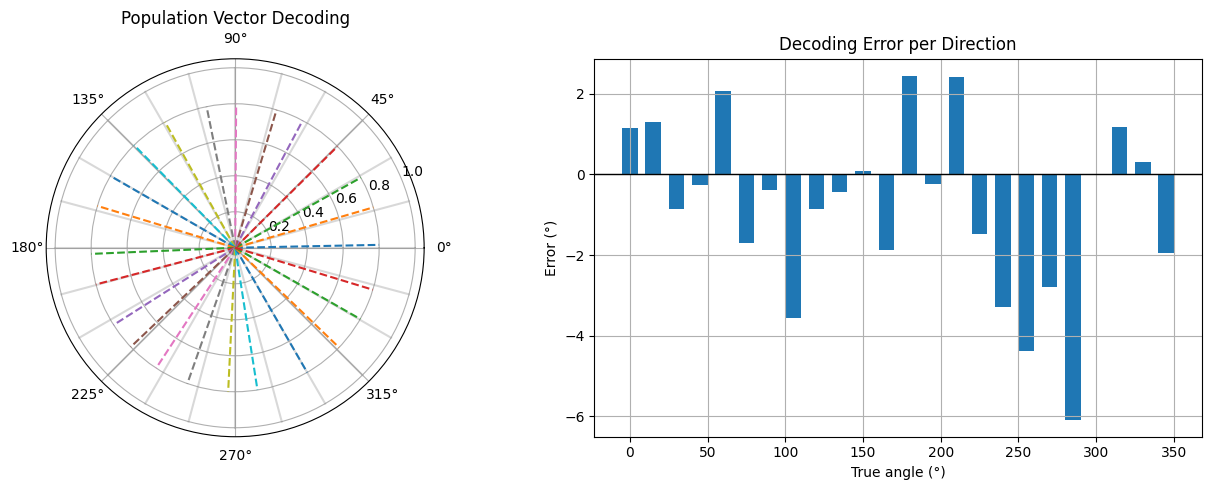

In [6]:
# --- TODO 4: Plot decoding results ---

fig = plt.figure(figsize=(13, 5))

ax_polar = fig.add_subplot(1, 2, 1, projection='polar')

# TODO: draw true and decoded direction lines
# Hint:
# np.deg2rad(...) converts degrees to radians
for i, true_ang in enumerate(true_angles_rad):
    # True direction (solid line)
    ax_polar.plot([0, true_ang], [0, 1], color='gray', alpha=0.3)
    # Decoded direction (dashed line)
    decoded_rad = np.deg2rad(decoded_angles_deg[i])
    ax_polar.plot([0, decoded_rad], [0, 0.8], linestyle='--')

ax_polar.set_title("Population Vector Decoding")

ax_err = fig.add_subplot(1, 2, 2)

# TODO: bar chart of angular_errors
# TODO: add horizontal line at 0
# (In ax_err)
ax_err.bar(TRUE_ANGLES_DEG, angular_errors, width=10)
ax_err.axhline(0, color='black', linewidth=1)

ax_err.set_xlabel("True angle (°)")
ax_err.set_ylabel("Error (°)")
ax_err.set_title("Decoding Error per Direction")
ax_err.grid(True)

plt.tight_layout()
plt.show()

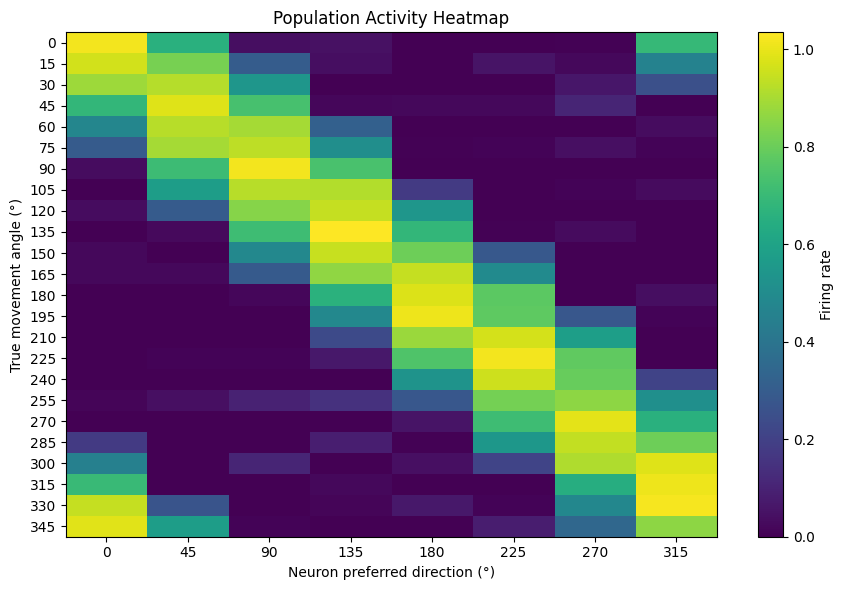

In [7]:
# ------------------------------------------------------------
# TODO 5: Plot population activity heatmap
# Hint:
# rows = true angles
# cols = neurons
# use cmap='viridis'
# ------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 6))

im = ax2.imshow(all_rates_matrix, cmap='viridis', aspect='auto')

ax2.set_xlabel("Neuron preferred direction (°)")
ax2.set_ylabel("True movement angle (°)")
ax2.set_title("Population Activity Heatmap")

ax2.set_xticks(np.arange(len(pref_dirs_deg)))
ax2.set_xticklabels([f"{int(d)}" for d in pref_dirs_deg])

ax2.set_yticks(np.arange(len(TRUE_ANGLES_DEG)))
ax2.set_yticklabels([f"{int(a)}" for a in TRUE_ANGLES_DEG])

cbar = plt.colorbar(im, ax=ax2)
cbar.set_label("Firing rate")

plt.tight_layout()
plt.show()